---
title: 'Optimale Finanzierung'
author: 'Jacques Mock Schindler'
format: typst
df-print: kable
---


# Optimale Finanzierung

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
fk = np.linspace(1,99, 2000)

In [ ]:
df = pd.DataFrame(fk, columns=['FK'])
df['EK'] = 100 - df['FK']
df['EBIT'] = 10

# RoI einheitlich in % (10%)
df['RoI'] = (df['EBIT'] / (df['FK'] + df['EK'])) * 100

# Szenario A: Günstiger Zins (5%) -> Positiver Leverage-Effekt
df['Gewinn5'] = df['EBIT'] - (df['FK'] * 0.05)
df['RoE5'] = (df['Gewinn5'] / df['EK']) * 100

# Szenario B: Teurer Zins (15%) -> Negativer Leverage-Effekt
df['Gewinn15'] = df['EBIT'] - (df['FK'] * 0.15)
df['RoE15'] = (df['Gewinn15'] / df['EK']) * 100

df = df.round(2)
df

,FK,EK,EBIT,RoI,Gewinn5,RoE5,Gewinn15,RoE15
0,1.00,99.00,10,10.0,9.95,10.05,9.85,9.95
1,1.05,98.95,10,10.0,9.95,10.05,9.84,9.95
2,1.10,98.90,10,10.0,9.95,10.06,9.84,9.94
3,1.15,98.85,10,10.0,9.94,10.06,9.83,9.94
4,1.20,98.80,10,10.0,9.94,10.06,9.82,9.94
...,...,...,...,...,...,...,...,...
1995,98.80,1.20,10,10.0,5.06,423.03,-4.82,-403.03
1996,98.85,1.15,10,10.0,5.06,440.89,-4.83,-420.89
1997,98.90,1.10,10,10.0,5.05,460.35,-4.84,-440.35
1998,98.95,1.05,10,10.0,5.05,481.63,-4.84,-461.63


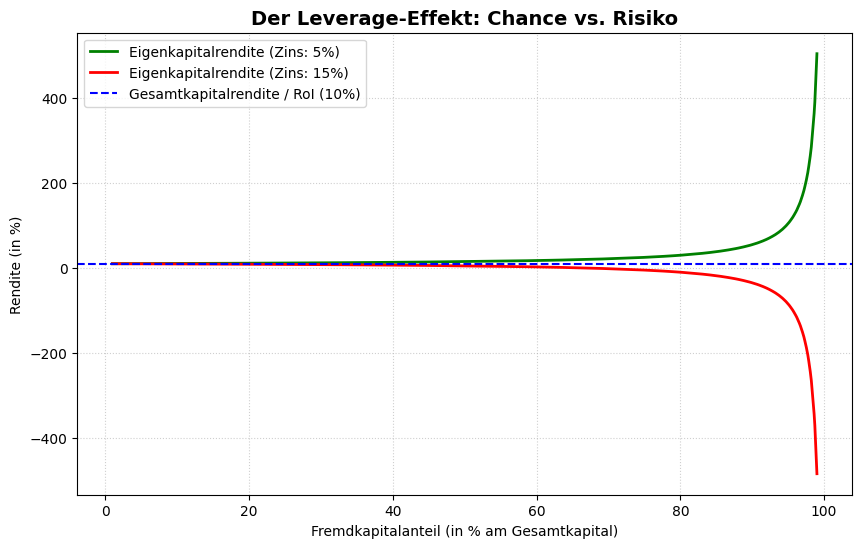

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# Wir plotten gegen das FK auf der X-Achse!
ax.plot(df['FK'], df['RoE5'], label='Eigenkapitalrendite (Zins: 5%)', color='green', linewidth=2)
ax.plot(df['FK'], df['RoE15'], label='Eigenkapitalrendite (Zins: 15%)', color='red', linewidth=2)

# Die Nulllinie für die Gesamtkapitalrendite (RoI)
ax.axhline(y=10, color='blue', linestyle='--', label='Gesamtkapitalrendite / RoI (10%)')

# Beschriftungen vollkommen eindeutig machen
ax.set_xlabel('Fremdkapitalanteil (in % am Gesamtkapital)')
ax.set_ylabel('Rendite (in %)')
ax.set_title('Der Leverage-Effekt: Chance vs. Risiko', fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, linestyle=':', alpha=0.6)

plt.show()

In [ ]:
from matplotlib import lines
def plot_leverage(roi: float, interest_rate: float):
    if roi > 1:
        roi = roi / 100
    if interest_rate > 1:
        interest_rate = interest_rate / 100

    liabilities = np.linspace(10,90,2000)
    df = pd.DataFrame(liabilities, columns=['Liabilities'])
    df['Assets'] = 100 - df['Liabilities']
    df['EBIT'] = 100 * roi
    df['Profit'] = df['EBIT'] - (df['Liabilities'] * interest_rate)
    df['RoE'] = (df['Profit'] / df['Assets']) * 100
    df['RoI'] = roi * 100
    df['Interest Rate'] = interest_rate * 100
    df = df.round(2)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(df['Liabilities'], df['RoE'], label='RoE',
            color='green', linewidth=2)
    ax.plot(df['Liabilities'], df['Interest Rate'], label='Interest Rate',
            color='red')
    ax.plot(df['Liabilities'], df['RoI'], label='RoI', color='blue')
    ax.axhline(y=0, linestyle='--', color='black')
    ax.set_ylabel('Return (in %)')
    ax.set_xlabel('Liabilities (in %)')
    ax.set_title('Leverage Effect', fontsize=14, fontweight='bold')
    ax.legend(loc='upper left')
    plt.show()
    print(df.head())

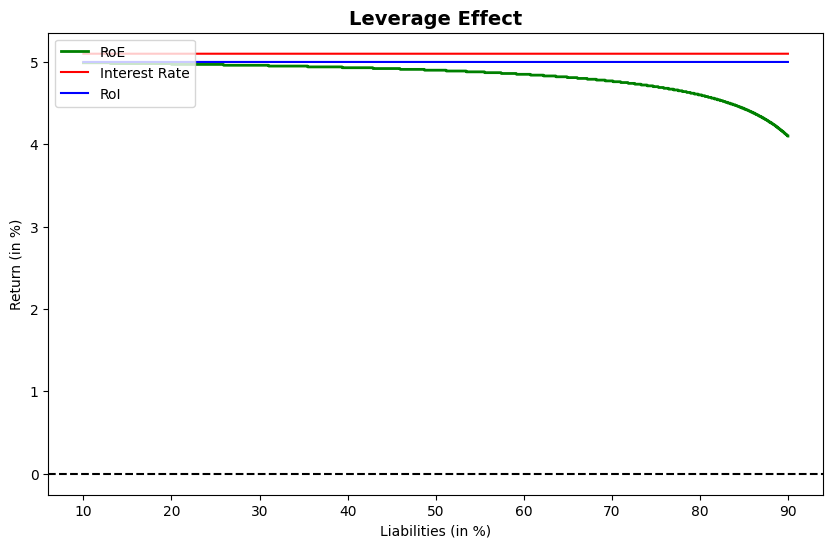

   Liabilities  Assets  EBIT  Profit   RoE  RoI  Interest Rate
0        10.00   90.00   5.0    4.49  4.99  5.0            5.1
1        10.04   89.96   5.0    4.49  4.99  5.0            5.1
2        10.08   89.92   5.0    4.49  4.99  5.0            5.1
3        10.12   89.88   5.0    4.48  4.99  5.0            5.1
4        10.16   89.84   5.0    4.48  4.99  5.0            5.1


In [ ]:
plot_leverage(5, 5.1)

Auftrag: Beobachtung als Text formulieren.

$$
\text{RoE} = \text{RoI} + \frac{\text{FK}}{\text{EK}} \cdot (\text{RoI} - i)
$$